<a href="https://colab.research.google.com/github/lathikasuriyamoorthy-29/trendpulse-lathikasuriyamoorthy/blob/main/task4_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from google.colab import files

uploaded = files.upload()

Saving trends_analyzed (2).csv to trends_analyzed (2).csv


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [28]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (76, 11)


In [29]:
df.head()

,post_id,title,category,score,num_comments,author,collected_at,engagement,is_popuar,is_popluar,is_popular
0,49875913,"Parley: Federated, decentralised chat that spe...",technology,22,6,davidcollantes,2026-09-28 16:41:46.649469,0.260870,False,False,False
1,49873241,Thinking fast and slow in AI: The role of meta...,technology,113,36,teleforce,2026-09-28 16:41:48.783910,0.315789,False,False,False
2,49872883,Nissan's third generation e-POWER powertrain,technology,75,91,mroche,2026-09-28 16:41:51.587481,1.197368,False,False,False
3,49869755,Malleable software: Restoring user agency in a...,technology,102,48,evakhoury,2026-09-28 16:41:53.106822,0.466019,False,False,False
4,49875148,AI companies in race to demonstrate their mode...,technology,9,0,ljewalsh,2026-09-28 16:41:57.061899,0.000000,False,False,False


In [30]:
os.makedirs("outputs", exist_ok=True)

In [31]:
top_10 = df.nlargest(10, "score").copy()

In [32]:
top_10["short_title"] = top_10["title"].apply(
    lambda title: title[:50] + "..." if len(title) > 50 else title)

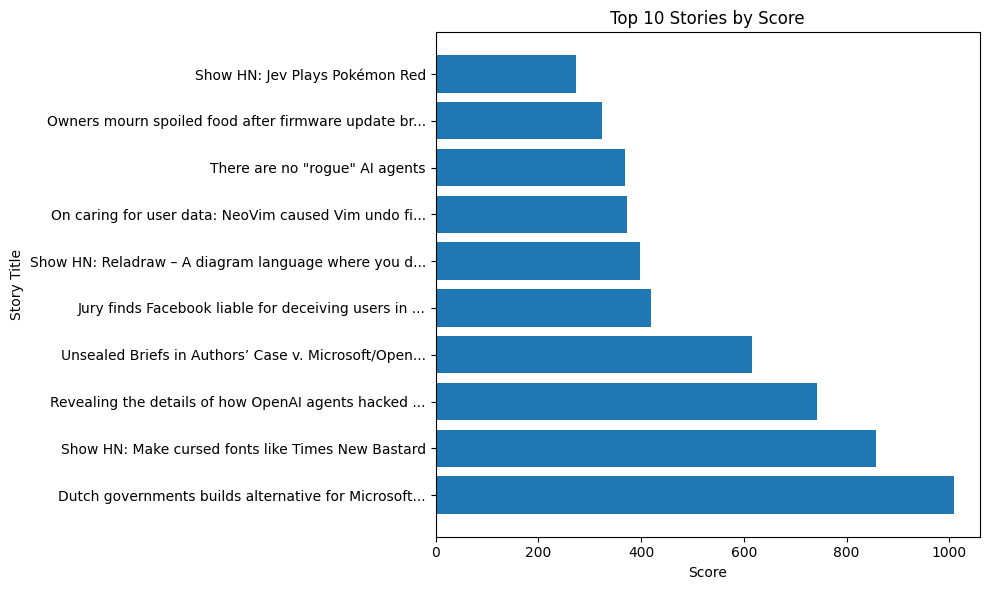

In [33]:
plt.figure(figsize=(10, 6))

plt.barh(top_10["short_title"], top_10["score"])

plt.xlabel("Score")
plt.ylabel("Story Title")
plt.title("Top 10 Stories by Score")

plt.tight_layout()

plt.savefig("outputs/chart1_top_stories.png")

plt.show()

In [34]:
category_counts = df["category"].value_counts()

print(category_counts)

category
technology       24
entertainment    24
worldnews        12
science          10
sports            6
Name: count, dtype: int64


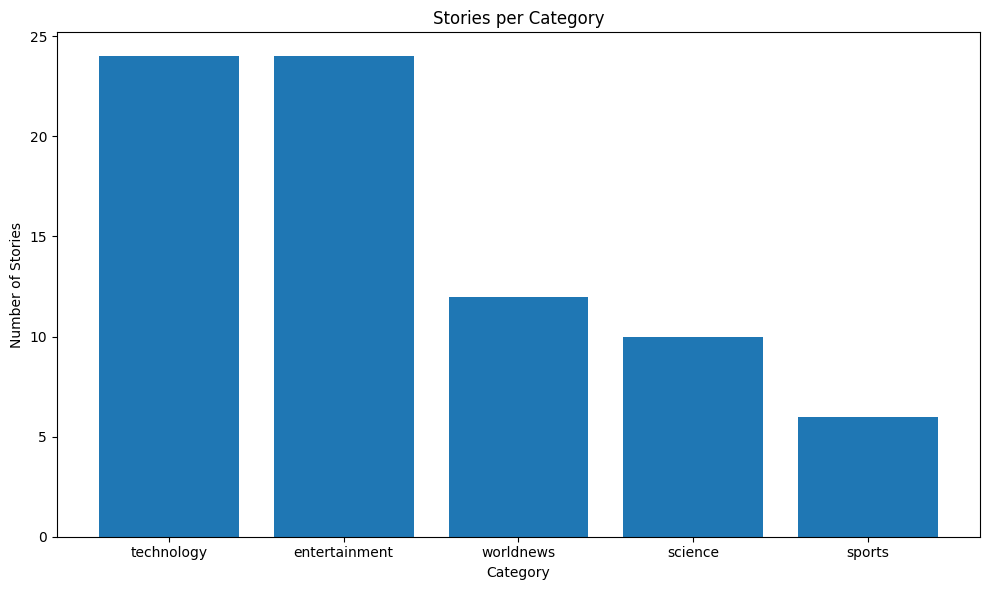

In [35]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.xlabel("Category")
plt.ylabel("Number of Stories")
plt.title("Stories per Category")

plt.tight_layout()

plt.savefig("outputs/chart2_categories.png")

plt.show()

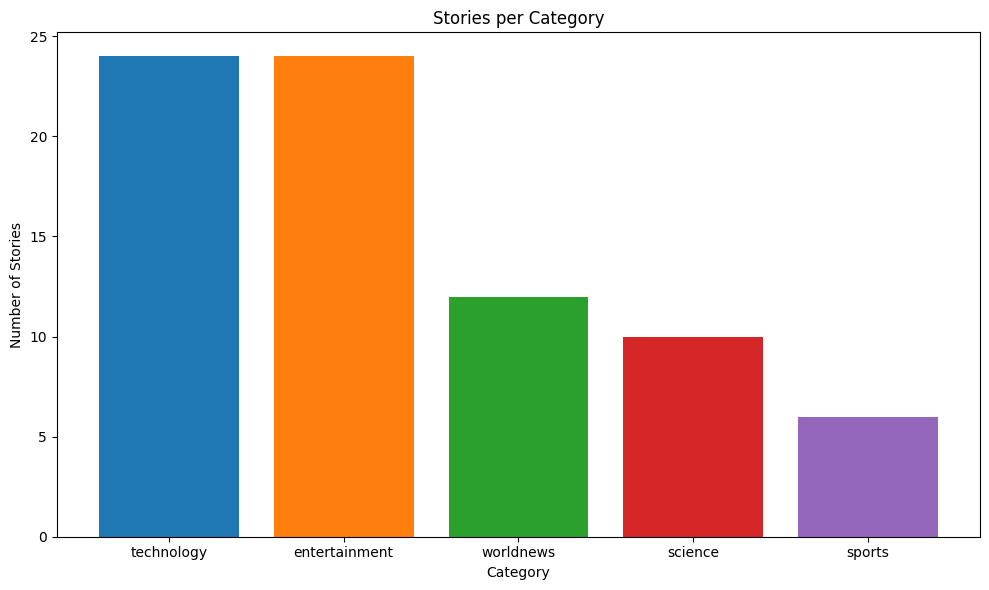

In [36]:
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(range(len(category_counts)))

plt.bar(
    category_counts.index,
    category_counts.values,
    color=colors
)

plt.xlabel("Category")
plt.ylabel("Number of Stories")
plt.title("Stories per Category")

plt.tight_layout()

plt.savefig("outputs/chart2_categories.png")

plt.show()

In [37]:
popular = df[df["is_popular"] == True]

not_popular = df[df["is_popular"] == False]

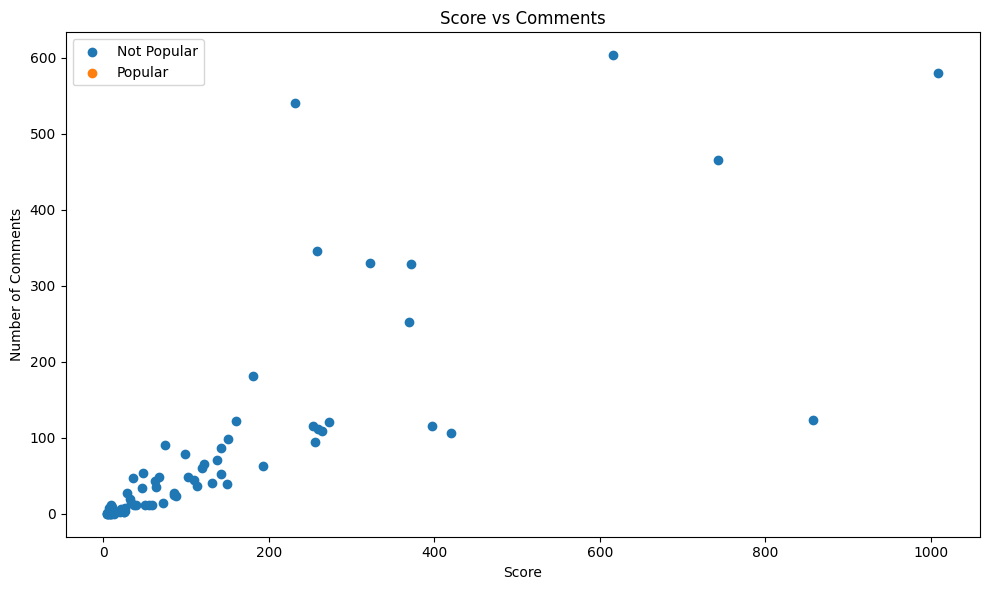

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    not_popular["score"],
    not_popular["num_comments"],
    label="Not Popular"
)

plt.scatter(
    popular["score"],
    popular["num_comments"],
    label="Popular"
)

plt.xlabel("Score")
plt.ylabel("Number of Comments")
plt.title("Score vs Comments")

plt.legend()

plt.tight_layout()

plt.savefig("outputs/chart3_scatter.png")

plt.show()

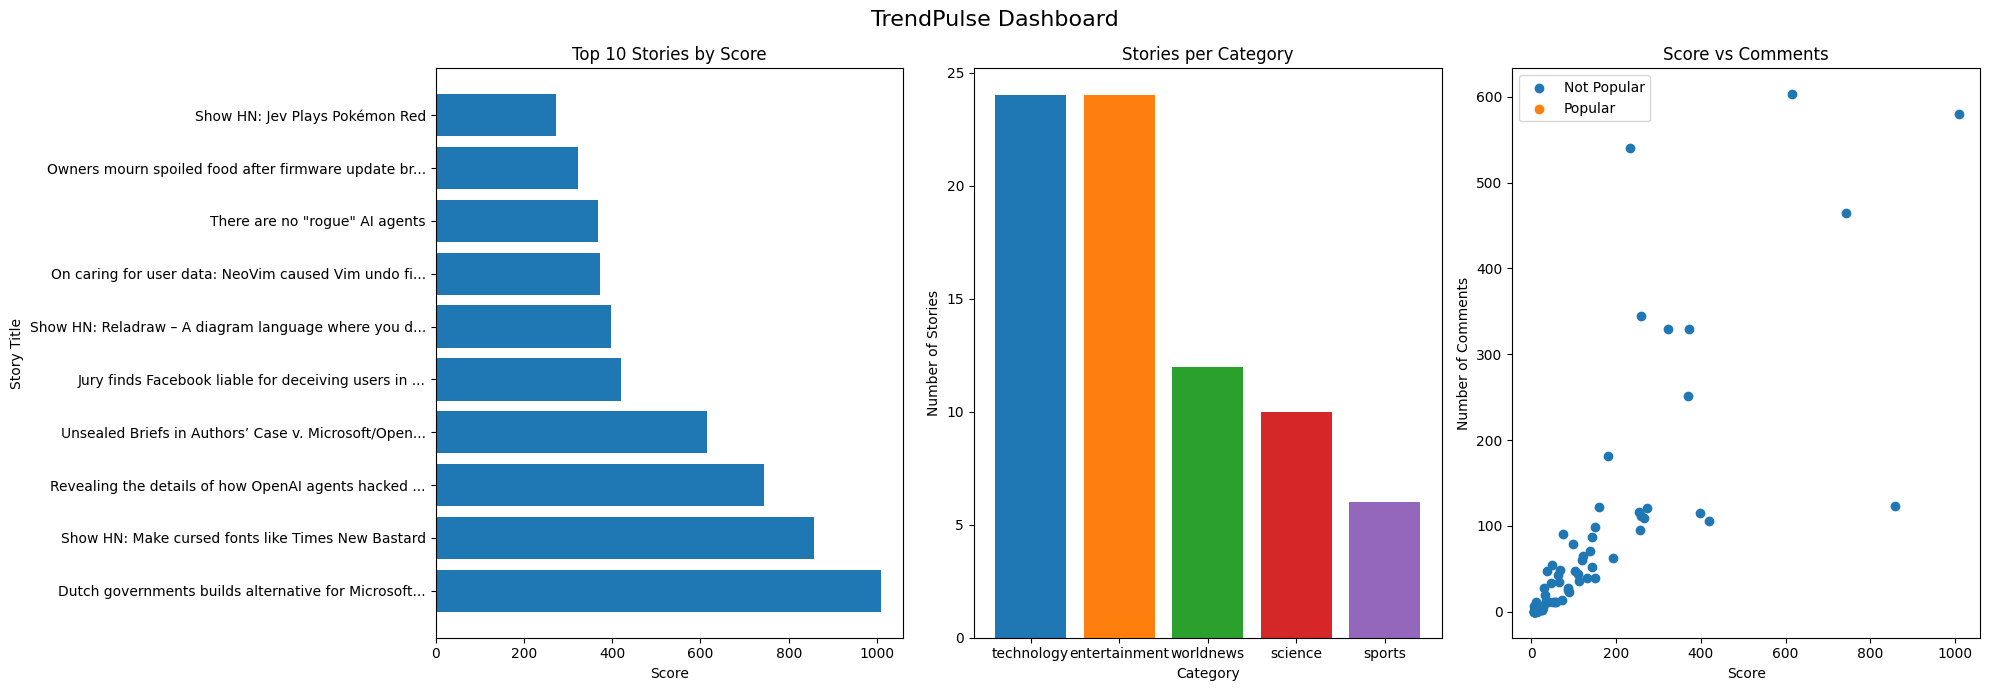

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))


# Chart 1 — Top 10 Stories
axes[0].barh(
    top_10["short_title"],
    top_10["score"]
)

axes[0].set_xlabel("Score")
axes[0].set_ylabel("Story Title")
axes[0].set_title("Top 10 Stories by Score")


# Chart 2 — Stories per Category
axes[1].bar(
    category_counts.index,
    category_counts.values,
    color=plt.cm.tab10(range(len(category_counts)))
)

axes[1].set_xlabel("Category")
axes[1].set_ylabel("Number of Stories")
axes[1].set_title("Stories per Category")


# Chart 3 — Score vs Comments
axes[2].scatter(
    not_popular["score"],
    not_popular["num_comments"],
    label="Not Popular"
)

axes[2].scatter(
    popular["score"],
    popular["num_comments"],
    label="Popular"
)

axes[2].set_xlabel("Score")
axes[2].set_ylabel("Number of Comments")
axes[2].set_title("Score vs Comments")
axes[2].legend()


# Overall title
fig.suptitle("TrendPulse Dashboard", fontsize=16)

plt.tight_layout()

plt.savefig("outputs/dashboard.png")

plt.show()

In [45]:
import os

print(os.listdir("outputs"))

['chart2_categories.png', 'dashboard.png', 'chart3_scatter.png', 'chart1_top_stories.png']


In [47]:
from google.colab import files

files.download("outputs/chart1_top_stories.png")
files.download("outputs/chart2_categories.png")
files.download("outputs/chart3_scatter.png")
files.download("outputs/dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>